# GCN–Cora: từ đồ thị đến nhãn bài báo
Chạy lần lượt. Cell đầu chuẩn bị repo khi dùng Colab; chạy local từ thư mục repo hoặc notebooks cũng được.

In [1]:
from pathlib import Path
import os
if not Path('cora.py').exists():
    if Path('../cora.py').exists():
        os.chdir('..')
    else:
        import subprocess
        if not Path('/content/gnn/cora.py').exists():
            subprocess.run(['git', 'clone', 'https://github.com/dungTudonghoa/gnn.git', '/content/gnn'], check=True)
        os.chdir('/content/gnn')
%pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.9 MB/s eta 0:00:00


## 1. Tạo đồ thị nhỏ
Node là đối tượng; cạnh là mối quan hệ có hướng. Đây là ví dụ minh họa, chưa phải Cora.

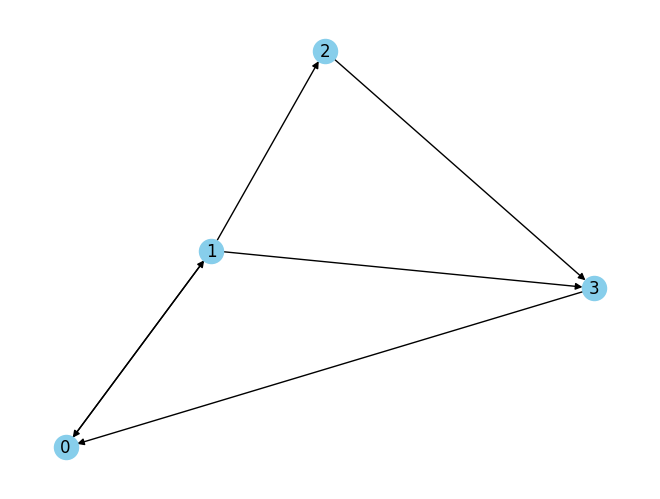

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
g = nx.DiGraph([(0,1),(1,2),(1,0),(1,3),(2,3),(3,0)])
nx.draw(g, pos=nx.spring_layout(g, seed=42), with_labels=True, node_color='skyblue', arrows=True)
plt.show()

## 2. Quan sát Cora
Một đồ thị, 2708 bài báo. Mỗi bài có 1433 đặc trưng; nhãn thuộc 7 lớp. `Planetoid` tải tensor đã tiền xử lý, không tải văn bản PDF.

In [3]:
from cora import load_data, inspect_data
dataset = load_data()
inspect_data(dataset)
data = dataset[0]
print('Shape:', data.x.shape, data.edge_index.shape, data.y.shape)
print('Tổng hàng đầu:', data.x[0].sum().item())

Processing...


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
Số đồ thị: 1
train_mask 140
val_mask 500
test_mask 1000
Đặc trưng khác 0 của node 0: [19, 81, 146, 315, 774, 877, 1194, 1247, 1274]
Giá trị tương ứng: [0.1111111119389534, 0.1111111119389534, 0.1111111119389534, 0.1111111119389534, 0.1111111119389534, 0.1111111119389534, 0.1111111119389534, 0.1111111119389534, 0.1111111119389534]
10 cạnh đầu (source, target): [[633, 0], [1862, 0], [2582, 0], [2, 1], [652, 1], [654, 1], [1, 2], [332, 2], [1454, 2], [1666, 2]]
10 nhãn đầu: [3, 4, 4, 0, 3, 2, 0, 3, 3, 2]
Các file nguồn Planetoid: ['data/Planetoid/Cora/raw/ind.cora.x', 'data/Planetoid/Cora/raw/ind.cora.tx', 'data/Planetoid/Cora/raw/ind.cora.allx', 'data/Planetoid/Cora/raw/ind.cora.y', 'data/Planetoid/Cora/raw/ind.cora.ty', 'data/Planetoid/Cora/raw/ind.cora.ally', 'data/Planetoid/Cora/raw/ind.cora.graph', 'data/Planetoid/Cora/raw/ind.cora.test.index']
Shape: torch.Size([2708, 1433]) t

Done!


In [4]:
source, target = data.edge_index[:, 0].tolist()
print('Cạnh đầu:', source, '->', target)
print('Đặc trưng nguồn:', data.x[source])
print('Đặc trưng đích:', data.x[target])
assert not (data.train_mask & data.test_mask).any()
assert not (data.train_mask & data.val_mask).any()
assert not (data.val_mask & data.test_mask).any()

Cạnh đầu: 633 -> 0
Đặc trưng nguồn: tensor([0., 0., 0.,  ..., 0., 0., 0.])
Đặc trưng đích: tensor([0., 0., 0.,  ..., 0., 0., 0.])


## 3. Huấn luyện
GCN: 1433 → 16 → 7. Chỉ 140 nhãn train được dùng trong loss, nhưng toàn bộ đồ thị tham gia message passing. Test chỉ đánh giá cuối. t-SNE có thể mất thêm thời gian trên CPU.

In [5]:
from cora import run
model, data, history, metrics = run()

Epoch 001 | loss=1.9465 | val=0.1660
Epoch 010 | loss=1.8764 | val=0.4280
Epoch 020 | loss=1.7568 | val=0.6180
Epoch 030 | loss=1.6102 | val=0.7200
Epoch 040 | loss=1.3972 | val=0.7360
Epoch 050 | loss=1.2543 | val=0.7520
Epoch 060 | loss=1.0201 | val=0.7540
Epoch 070 | loss=0.8818 | val=0.7780
Epoch 080 | loss=0.8277 | val=0.7740
Epoch 090 | loss=0.6746 | val=0.7740
Epoch 100 | loss=0.6375 | val=0.7840
{
  "epochs": 100,
  "seed": 1234567,
  "device": "cpu",
  "torch_version": "2.9.0+cpu",
  "val_accuracy": 0.7839999794960022,
  "test_accuracy": 0.8109999895095825
}


## 4. Quan sát học và biểu diễn
Màu trên hình t-SNE là nhãn thật, không phải nhãn dự đoán.

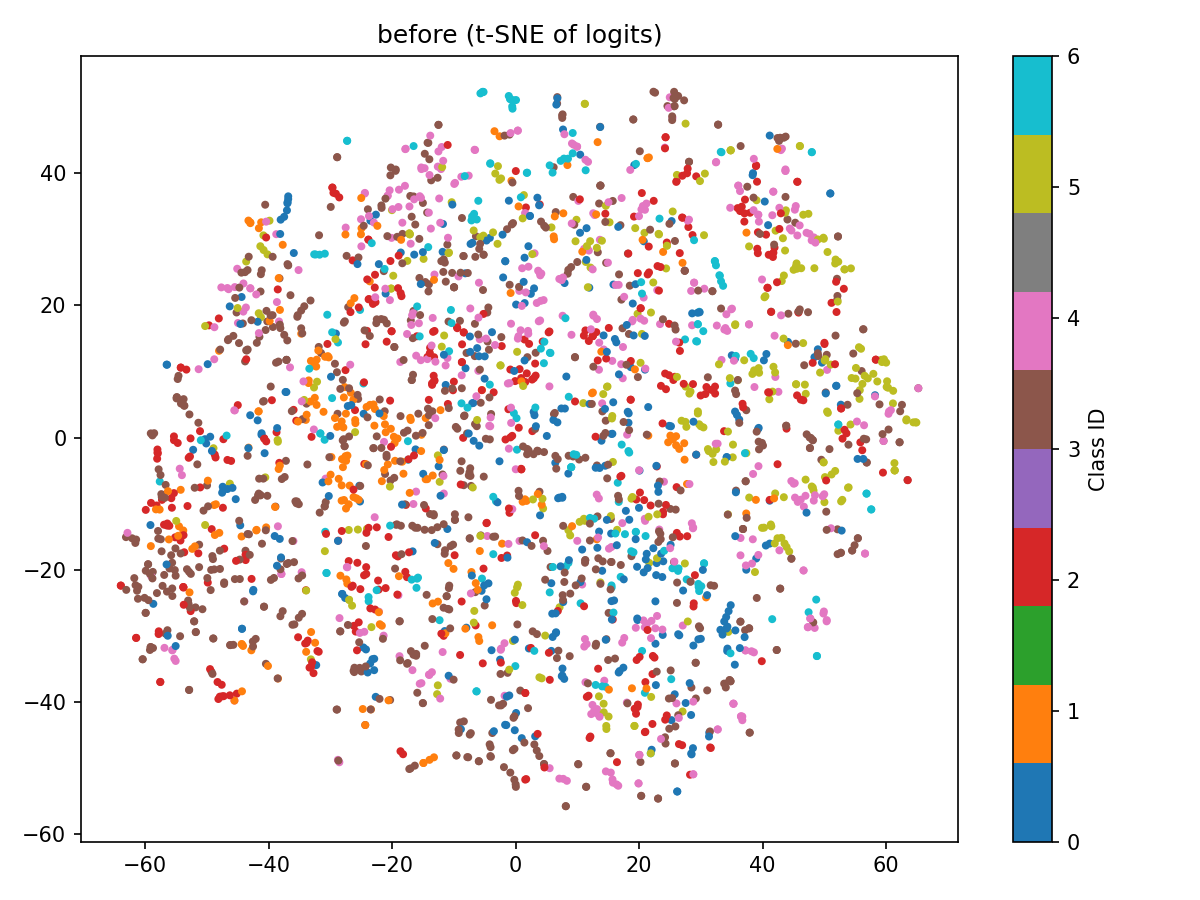

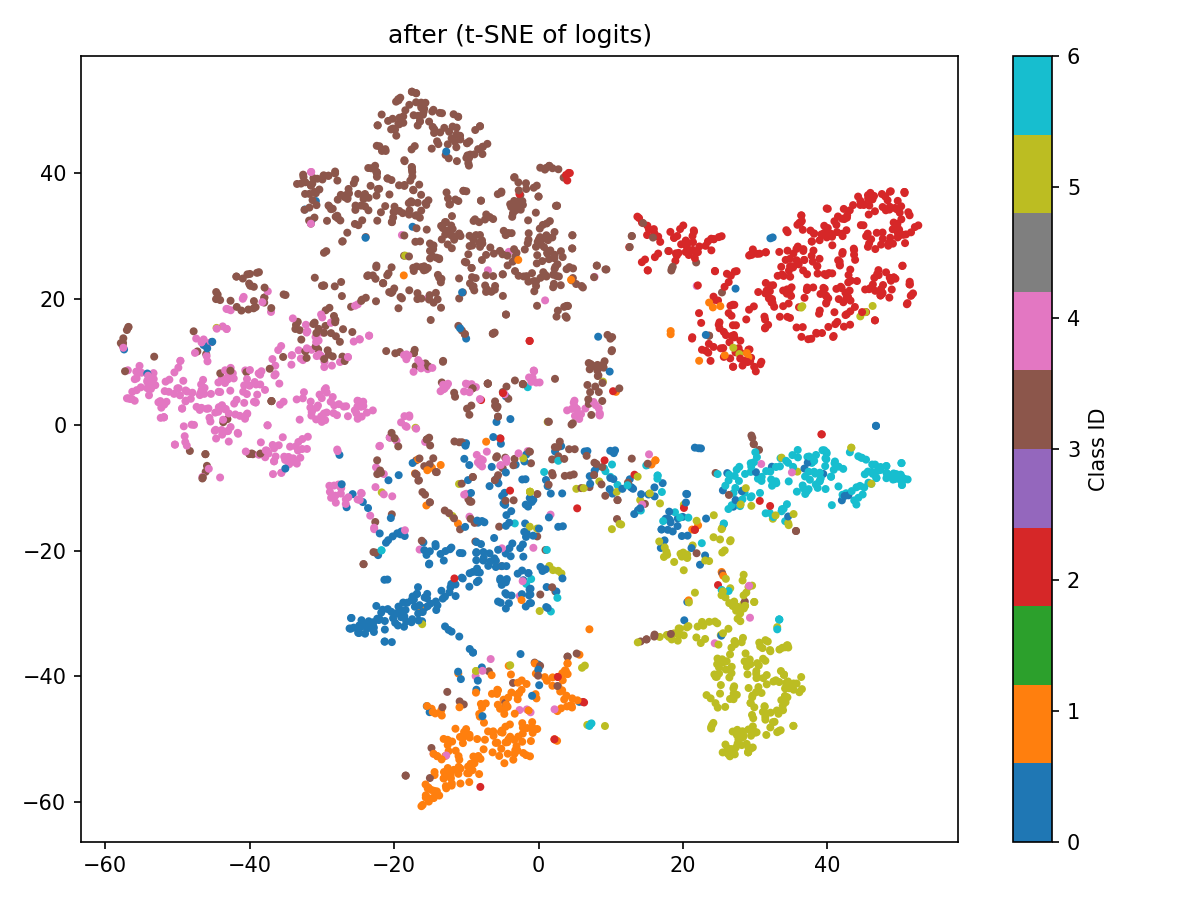

In [6]:
from IPython.display import Image, display
plt.plot([row['epoch'] for row in history], [row['loss'] for row in history])
plt.xlabel('Epoch'); plt.ylabel('Train loss'); plt.show()
display(Image(filename='outputs/before.png'))
display(Image(filename='outputs/after.png'))

## 5. Dự đoán một node test
Logits không phải xác suất; softmax đổi sang xác suất trên 7 lớp. Kết quả là một nhãn cho node.

In [7]:
import torch
model.eval()
with torch.no_grad():
    probabilities = model(data.x, data.edge_index).softmax(dim=1)
node = data.test_mask.nonzero()[0].item()
print('Node:', node)
print('Probabilities:', probabilities[node].cpu().tolist())
print('Predicted:', probabilities[node].argmax().item(), 'True:', data.y[node].item())

Node: 1708
Probabilities: [0.19111351668834686, 0.18137222528457642, 0.11627507954835892, 0.150472491979599, 0.12720313668251038, 0.1442631483078003, 0.0893004760146141]
Predicted: 0 True: 3


## Bài tập
- Vì sao `edge_index` có 2 hàng?
- Vì sao đầu ra có 2708 hàng dù chỉ 140 nhãn train?
- Khác biệt giữa logits, softmax và argmax?
- Vì sao không dùng test accuracy để chọn epoch?

Nguồn và hướng dẫn chi tiết: [README](../README.md).